In [1]:
import pandas as pd
import numpy as np
import warnings

# Configuración de rutas
FILE_PATH_PARQUET = '/home/quant/data/processed/nq_1m_continuous.parquet'

def capa_0_datos(path):
    """
    Capa 0: Carga, Warm-up de indicadores y Filtrado de Sesión.
    """
    # Silenciamos advertencias de frecuencia si fuera necesario, 
    # aunque lo corregiremos directamente en el código.
    print(f"🚀 Cargando dataset desde: {path}")
    
    # 1. Carga del archivo Parquet
    df = pd.read_parquet(path)
    df.index = pd.to_datetime(df.index)
    
    # Asegurar que el índice sea local (NY) y sin zona horaria para cálculos rápidos
    if df.index.tz is not None:
        df.index = df.index.tz_convert('America/New_York').tz_localize(None)
    
    # 2. Cálculo de EMAs sobre el dataset COMPLETO (Warm-up)
    
    # EMAs de 1 Minuto
    periodos_1m = [1, 9, 12, 21, 50]
    for p in periodos_1m:
        df[f'EMA_1m_{p}'] = df['Close'].ewm(span=p, adjust=False).mean()
        
    # EMAs de 1 Hora (Estructurales)
    # Corrección de Warning: usamos '1h' en lugar de '1H'
    df_1h = df.resample('1h').last().copy()
    periodos_1h = [20, 50, 100, 200]
    for p in periodos_1h:
        df_1h[f'EMA_1h_{p}'] = df_1h['Close'].ewm(span=p, adjust=False).mean()
    
    # Desplazamos 1 periodo las EMAs de 1h para usar solo info CERRADA
    # Nota: Esto genera NaNs en el primer registro histórico de la base de datos
    df_1h_shifted = df_1h[[f'EMA_1h_{p}' for p in periodos_1h]].shift(1)
    
    # Unir EMAs 1h al dataframe principal
    df = df.join(df_1h_shifted, how='left')
    df[[f'EMA_1h_{p}' for p in periodos_1h]] = df[[f'EMA_1h_{p}' for p in periodos_1h]].ffill()
    
    # 3. Filtrado de Sesión Operativa
    # Recortamos el dataframe para el backtest (09:30 a 18:00)
    df_session = df.between_time('09:30', '18:00').copy()
    
    # Limpieza de registros iniciales sin indicadores calculados (NaNs de la EMA 200h)
    # Esto elimina los primeros días del historial donde la EMA200h aún no existe.
    df_session = df_session.dropna(subset=[f'EMA_1h_200'])
    
    print(f"✅ Capa 0 Completada (Warning corregido y NaNs filtrados).")
    print(f"Velas procesadas: {len(df_session)}")
    print(f"Rango operativo real: {df_session.index.min()} a {df_session.index.max()}")
    
    return df_session

# --- EJECUCIÓN ---
df_ready = capa_0_datos(FILE_PATH_PARQUET)
df_ready.head()

🚀 Cargando dataset desde: /home/quant/data/processed/nq_1m_continuous.parquet
✅ Capa 0 Completada (Warning corregido y NaNs filtrados).
Velas procesadas: 1738894
Rango operativo real: 2010-06-07 09:30:00 a 2025-12-12 16:59:00


,Open,High,Low,Close,Volume,Ticker,EMA_1m_1,EMA_1m_9,EMA_1m_12,EMA_1m_21,EMA_1m_50,EMA_1h_20,EMA_1h_50,EMA_1h_100,EMA_1h_200
timestamp,,,,,,,,,,,,,,,
2010-06-07 09:30:00,1841.25,1842.00,1838.75,1841.00,3113,NQM0,1841.00,1840.032226,1839.864509,1839.805139,1840.221120,1827.324773,1823.387119,1821.781056,1820.913594
2010-06-07 09:31:00,1840.75,1843.75,1840.50,1842.75,1596,NQM0,1842.75,1840.575781,1840.308431,1840.072854,1840.320292,1827.324773,1823.387119,1821.781056,1820.913594
2010-06-07 09:32:00,1842.75,1844.25,1841.50,1843.75,1377,NQM0,1843.75,1841.210625,1840.837903,1840.407140,1840.454791,1827.324773,1823.387119,1821.781056,1820.913594
2010-06-07 09:33:00,1843.75,1844.00,1839.50,1839.50,1274,NQM0,1839.50,1840.868500,1840.632072,1840.324672,1840.417348,1827.324773,1823.387119,1821.781056,1820.913594
2010-06-07 09:34:00,1839.50,1840.75,1837.00,1837.75,1566,NQM0,1837.75,1840.244800,1840.188676,1840.090611,1840.312746,1827.324773,1823.387119,1821.781056,1820.913594


In [2]:
import pandas as pd
import numpy as np

def generar_trades_orb(df, breakout_delta=5.0):
    """
    Capa 1: Lógica de detección de ORB, confirmación de Breakout y ejecución en Midpoint.
    Limitado a 1 trade por día.
    """
    print(f"distancia de confirmación (BreakoutDelta): {breakout_delta} puntos.")
    
    # 1. Identificar días únicos en el dataset
    df['date'] = df.index.date
    unique_days = df['date'].unique()
    trades = []

    for day in unique_days:
        # Filtrar data del día
        df_day = df[df['date'] == day].copy()
        
        # 2. Definir el Rango ORB (09:30 - 09:34 inclusive)
        # Las primeras 5 velas de 1m definen el rango de 5m
        orb_data = df_day.between_time('09:30', '09:34')
        if len(orb_data) < 5:
            continue
            
        orb_h = orb_data['High'].max()
        orb_l = orb_data['Low'].min()
        orb_m = (orb_h + orb_l) / 2
        
        # 3. Buscar Confirmación de Breakout (Post 09:34)
        # Solo evaluamos velas a partir de las 09:35
        post_orb = df_day.between_time('09:35', '16:00')
        
        confirmed_dir = None
        confirmation_time = None
        
        for ts, row in post_orb.iterrows():
            # Condición Long: Vela completa a distancia Delta sobre el High
            if row['Low'] >= (orb_h + breakout_delta):
                confirmed_dir = 'Long'
                confirmation_time = ts
                break
            
            # Condición Short: Vela completa a distancia Delta bajo el Low
            if row['High'] <= (orb_l - breakout_delta):
                confirmed_dir = 'Short'
                confirmation_time = ts
                break
        
        # 4. Si hay confirmación, buscar Retest al Midpoint
        if confirmed_dir:
            # Buscamos la entrada desde el minuto siguiente a la confirmación
            retest_data = post_orb.loc[confirmation_time:].iloc[1:]
            
            entry_time = None
            entry_price = orb_m
            
            for ts_entry, row_entry in retest_data.iterrows():
                # El precio debe cruzar o tocar el midpoint para gatillar
                if confirmed_dir == 'Long':
                    # En un Long, venimos de arriba, buscamos Low <= Midpoint
                    if row_entry['Low'] <= orb_m:
                        entry_time = ts_entry
                        break
                else:
                    # En un Short, venimos de abajo, buscamos High >= Midpoint
                    if row_entry['High'] >= orb_m:
                        entry_time = ts_entry
                        break
            
            # 5. Registrar el Trade si hubo entrada
            if entry_time:
                # Valores adicionales importantes para optimización
                trade_info = {
                    'fecha': day,
                    'orb_high': orb_h,
                    'orb_low': orb_l,
                    'midpoint': orb_m,
                    'direccion': confirmed_dir,
                    'confirmacion_dt': confirmation_time,
                    'entrada_dt': entry_time,
                    'entrada_precio': entry_price,
                    # Referencias de mercado al momento de entrada
                    'ema_1h_50_entry': row_entry['EMA_1h_50'],
                    'ema_1m_21_entry': row_entry['EMA_1m_21'],
                    'ticker': row_entry['Ticker']
                }
                trades.append(trade_info)
                # Req Inmutable: Solo 1 trade al día. Pasamos al siguiente día.
                continue

    # Convertir a DataFrame de Trades
    df_trades = pd.DataFrame(trades)
    
    if not df_trades.empty:
        df_trades['entrada_dt'] = pd.to_datetime(df_trades['entrada_dt'])
        print(f"✅ Procesamiento completado. Trades generados: {len(df_trades)}")
    else:
        print("⚠️ No se generaron trades con los parámetros actuales.")
        
    return df_trades

# --- EJECUCIÓN ---
# Nota: df_ready viene de la Capa 0
df_trades_raw = generar_trades_orb(df_ready, breakout_delta=5.0)
df_trades_raw.head()

distancia de confirmación (BreakoutDelta): 5.0 puntos.
✅ Procesamiento completado. Trades generados: 2385


,fecha,orb_high,orb_low,midpoint,direccion,confirmacion_dt,entrada_dt,entrada_precio,ema_1h_50_entry,ema_1m_21_entry,ticker
0,2010-06-07,1844.25,1837.00,1840.625,Short,2010-06-07 09:43:00,2010-06-07 09:53:00,1840.625,1823.387119,1835.366356,NQM0
1,2010-06-08,1803.50,1796.50,1800.000,Short,2010-06-08 09:54:00,2010-06-08 11:57:00,1800.000,1810.597340,1794.184535,NQM0
2,2010-06-09,1808.75,1804.75,1806.750,Short,2010-06-09 10:05:00,2010-06-09 10:51:00,1806.750,1799.436594,1801.177908,NQM0
3,2010-06-10,1809.25,1801.00,1805.125,Long,2010-06-10 10:01:00,2010-06-10 12:44:00,1805.125,1796.663916,1808.125132,NQM0
4,2010-06-14,1864.25,1859.50,1861.875,Long,2010-06-14 10:17:00,2010-06-14 13:07:00,1861.875,1841.323032,1865.321516,NQU0


In [3]:
import pandas as pd
import numpy as np


def simular_gestion_riesgo(df_ready, df_trades, breakout_delta=5.0, be_trigger_r=1.0):
    """
    Capa 2: Simulación de gestión de riesgo con modelo secuencial OHLC/OLHC.
    Salidas: TP (2R), SL (Extremo ORB), BE (al tocar 1R).
    """
    print(f"🚀 Iniciando gestión de riesgo para {len(df_trades)} trades...")
    
    resultados = []



    for _, trade in df_trades.iterrows():
        # Extraer parámetros del trade
        entry_price = trade['entrada_precio']
        direction = trade['direccion']
        orb_h = trade['orb_high']
        orb_l = trade['orb_low']
        
        # Calcular distancias de riesgo (R)
        # R es la distancia del midpoint al extremo del ORB
        risk_r = abs(entry_price - (orb_l if direction == 'Long' else orb_h))
        if be_trigger_r is not None:
            be_trigger = (
                entry_price + (be_trigger_r * risk_r)
                if direction == 'Long'
                else entry_price - (be_trigger_r * risk_r)
            )
        else:
            be_trigger = None
            
        stop_loss = orb_l if direction == 'Long' else orb_h
        take_profit = entry_price + (2 * risk_r) if direction == 'Long' else entry_price - (2 * risk_r)
         # Obtener data desde el minuto de entrada hasta el fin de sesión
        df_day = df_ready[df_ready.index.date == trade['fecha']]
        df_post_entry = df_day.loc[trade['entrada_dt']:]
        
        current_sl = stop_loss
        be_activated = False
        exit_price = None
        exit_time = None
        exit_reason = None
        
        for ts, row in df_post_entry.iterrows():
            # Modelo Secuencial OHLC/OLHC para resolver conflictos intra-vela
            if row['Open'] <= row['Close']:
                # Vela Alcista: Open -> Low -> High -> Close
                sequence = [row['Open'], row['Low'], row['High'], row['Close']]
            else:
                # Vela Bajista: Open -> High -> Low -> Close
                sequence = [row['Open'], row['High'], row['Low'], row['Close']]
                
            for price_point in sequence:
                # 1. Verificar Trigger de Break Even (1R)
                if be_trigger_r is not None and not be_activated:
                    if (direction == 'Long' and price_point >= be_trigger) or \
                       (direction == 'Short' and price_point <= be_trigger):
                        current_sl = entry_price
                        be_activated = True
                
                # 2. Verificar Stop Loss (o BE si ya se activó)
                if (direction == 'Long' and price_point <= current_sl) or \
                   (direction == 'Short' and price_point >= current_sl):
                    exit_price = current_sl
                    exit_time = ts
                    exit_reason = 'SL' if not be_activated else 'BE'
                    break
                
                # 3. Verificar Take Profit (2R)
                if (direction == 'Long' and price_point >= take_profit) or \
                   (direction == 'Short' and price_point <= take_profit):
                    exit_price = take_profit
                    exit_time = ts
                    exit_reason = 'TP'
                    break
            
            if exit_time: break
            
        # 4. Cierre forzado EOD si no salió por niveles
        if not exit_time:
            exit_price = df_post_entry['Close'].iloc[-1]
            exit_time = df_post_entry.index[-1]
            exit_reason = 'EOD'

        # Cálculo de PnL en R
        pnl_r = (exit_price - entry_price) / risk_r if direction == 'Long' else (entry_price - exit_price) / risk_r
        
        # Guardar resultado extendido
        res = trade.to_dict()
        res.update({
            'salida_dt': exit_time,
            'salida_precio': exit_price,
            'motivo': exit_reason,
            'pnl_r': pnl_r,
            'be_activado': be_activated,
            'risk_r_puntos': risk_r
        })
        resultados.append(res)

    df_results = pd.DataFrame(resultados)
    print(f"✅ Gestión completada. Win Rate: {(df_results['pnl_r'] > 0).mean():.2%}")
    return df_results

# --- EJECUCIÓN ---
# df_ready (Capa 0) y df_trades_raw (Capa 1) deben estar en memoria
df_final_results = simular_gestion_riesgo(df_ready, df_trades_raw)
df_final_results[['fecha', 'direccion', 'motivo', 'pnl_r']].head(10)

🚀 Iniciando gestión de riesgo para 2385 trades...
✅ Gestión completada. Win Rate: 24.11%


,fecha,direccion,motivo,pnl_r
0,2010-06-07,Short,SL,-1.0
1,2010-06-08,Short,TP,2.0
2,2010-06-09,Short,BE,0.0
3,2010-06-10,Long,TP,2.0
4,2010-06-14,Long,BE,0.0
5,2010-06-17,Short,TP,2.0
6,2010-06-18,Long,SL,-1.0
7,2010-06-22,Long,BE,0.0
8,2010-06-23,Short,SL,-1.0
9,2010-06-24,Short,SL,-1.0


📊 Generando reporte de evaluación...
🔒 Filtrando trades por ventanas: 10-11, 12-13, 14-15...
------------------------------
📈 REPORTE DE PERFORMANCE (V38)
------------------------------
Total Trades:      1265
Win Rate:          26.56%
BE Rate:           34.62%
Loss Rate:         38.81%
Expectancy:        0.14 R
Profit Factor:     1.36
Max Drawdown:      -15.00 R
Resultado Final:   175.49 R
------------------------------


/tmp/ipykernel_20700/3822163333.py:84: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='dia_semana', y='pnl_r', data=df_results, order=order, ax=axes[1, 0], palette='viridis')


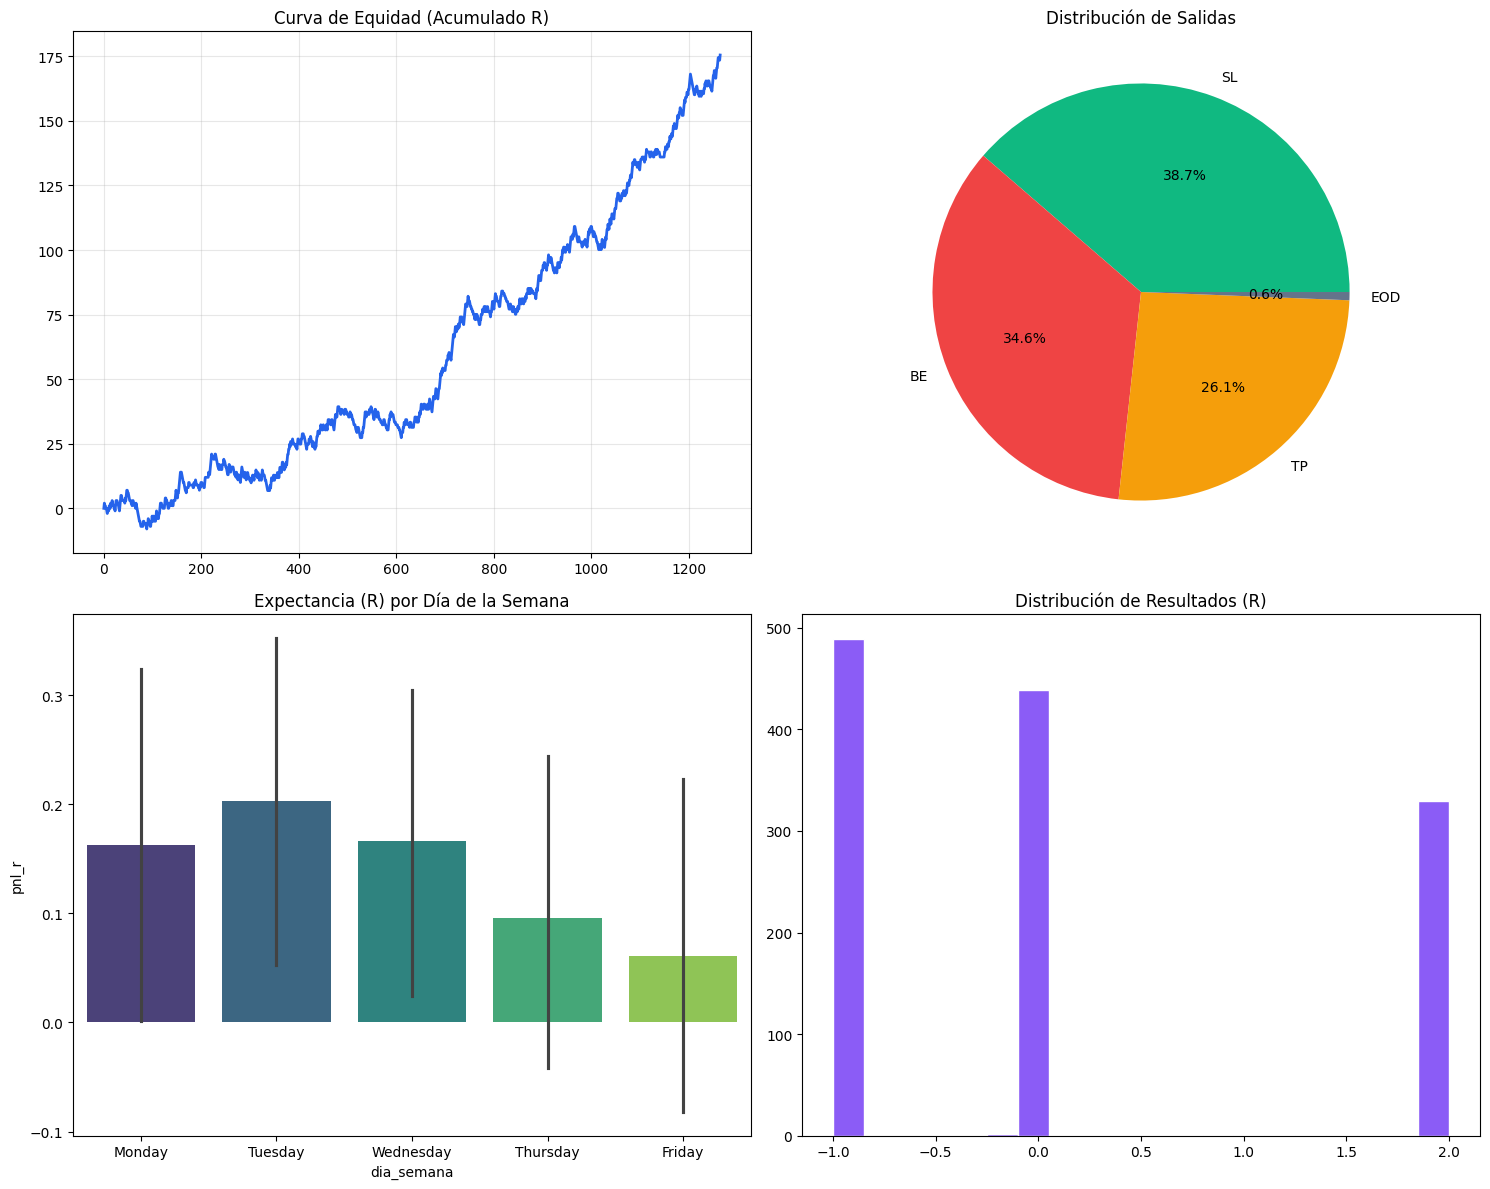

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def evaluar_estrategia(df_results):
    """
    Capa 4: Evaluación de métricas, análisis estadístico y visualización.
    Modificado para cumplir con REQ-EXEC-002 (Ventanas Operativas).
    """
    print("📊 Generando reporte de evaluación...")
    
    # --- FILTRO DE VENTANAS OPERATIVAS (REQ-EXEC-002) ---
    def esta_en_ventana(hora_str):
        h, m = map(int, hora_str.split(':'))
        t = h * 60 + m
        # 10:00-11:00 (600-660), 12:00-13:00 (720-780), 14:00-15:00 (840-900)
        ventanas = [(600, 660), (720, 780), (840, 900)]
        return any(inicio <= t < fin for inicio, fin in ventanas)

    if 'hora_entrada' not in df_results.columns:
        # Intentar extraer hora si no existe la columna pero sí el datetime
        df_results['hora_entrada'] = pd.to_datetime(df_results['entrada_dt']).dt.strftime('%H:%M')

    print("🔒 Filtrando trades por ventanas: 10-11, 12-13, 14-15...")
    df_results = df_results[df_results['hora_entrada'].apply(esta_en_ventana)].copy()

    if df_results.empty:
        print("⚠️ No hay trades que cumplan con las ventanas operativas.")
        return df_results

    # 1. Cálculos de Retorno Acumulado
    df_results = df_results.sort_values('fecha').copy()
    df_results['pnl_acumulado'] = df_results['pnl_r'].cumsum()
    
    # 2. Métricas Clave
    total_trades = len(df_results)
    win_rate = (df_results['pnl_r'] > 0).mean()
    be_rate = (df_results['pnl_r'] == 0).mean()
    loss_rate = (df_results['pnl_r'] < 0).mean()
    
    ganancia_total = df_results[df_results['pnl_r'] > 0]['pnl_r'].sum()
    perdida_total = abs(df_results[df_results['pnl_r'] < 0]['pnl_r'].sum())
    profit_factor = ganancia_total / perdida_total if perdida_total != 0 else np.inf
    
    expectancy = df_results['pnl_r'].mean() # Esperanza matemática por trade en R
    
    # Drawdown en R
    rolling_max = df_results['pnl_acumulado'].cummax()
    drawdown = df_results['pnl_acumulado'] - rolling_max
    max_drawdown = drawdown.min()
    
    # 3. Impresión de Reporte
    print("-" * 30)
    print(f"📈 REPORTE DE PERFORMANCE (V38)")
    print("-" * 30)
    print(f"Total Trades:      {total_trades}")
    print(f"Win Rate:          {win_rate:.2%}")
    print(f"BE Rate:           {be_rate:.2%}")
    print(f"Loss Rate:         {loss_rate:.2%}")
    print(f"Expectancy:        {expectancy:.2f} R")
    print(f"Profit Factor:     {profit_factor:.2f}")
    print(f"Max Drawdown:      {max_drawdown:.2f} R")
    print(f"Resultado Final:   {df_results['pnl_acumulado'].iloc[-1]:.2f} R")
    print("-" * 30)

    # 4. Visualización
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # A. Curva de Equidad
    axes[0, 0].plot(range(len(df_results)), df_results['pnl_acumulado'], color='#2563eb', lw=2)
    axes[0, 0].set_title("Curva de Equidad (Acumulado R)")
    axes[0, 0].grid(alpha=0.3)
    
    # B. Distribución de Motivos de Salida
    motivo_counts = df_results['motivo'].value_counts()
    axes[0, 1].pie(motivo_counts, labels=motivo_counts.index, autopct='%1.1f%%', 
                  colors=['#10b981', '#ef4444', '#f59e0b', '#64748b'])
    axes[0, 1].set_title("Distribución de Salidas")
    
    # C. PnL por Día de la Semana
    df_results['dia_semana'] = pd.to_datetime(df_results['fecha']).dt.day_name()
    order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
    sns.barplot(x='dia_semana', y='pnl_r', data=df_results, order=order, ax=axes[1, 0], palette='viridis')
    axes[1, 0].set_title("Expectancia (R) por Día de la Semana")
    
    # D. Histograma de PnL
    axes[1, 1].hist(df_results['pnl_r'], bins=20, color='#8b5cf6', edgecolor='white')
    axes[1, 1].set_title("Distribución de Resultados (R)")
    
    plt.tight_layout()
    plt.show()
    
    return df_results

# --- EJECUCIÓN ---
# df_final_results debe ser el DataFrame generado por la Capa 2
df_evaluado = evaluar_estrategia(df_final_results)

🧪 Iniciando barrido de sensibilidad basado en 'Reasons to sell'...
📦 Trades detectados para evaluar: 2385
----------------------------------------------------------------------
🚀 Iniciando gestión de riesgo para 2385 trades...
✅ Gestión completada. Win Rate: 35.30%
✅ Sin BE (Agresivo) procesado: 95.52R
🚀 Iniciando gestión de riesgo para 2385 trades...
✅ Gestión completada. Win Rate: 10.27%
✅ BE 0.5R (Muy Rápido) procesado: 116.07R
🚀 Iniciando gestión de riesgo para 2385 trades...
✅ Gestión completada. Win Rate: 24.11%
✅ BE 1.0R (Estándar V38) procesado: 149.28R
🚀 Iniciando gestión de riesgo para 2385 trades...
✅ Gestión completada. Win Rate: 31.45%
✅ BE 1.5R (Lento) procesado: 114.16R

📊 TABLA COMPARATIVA: IMPACTO DE LA PROTECCIÓN DE POSICIÓN


,Hipótesis BE,Trigger (R),Nº Trades,Win Rate %,BE Rate %,Expectancy (R),Max DD (R),PnL Total (R)
2,BE 1.0R (Estándar V38),1.0,2385,23.23,34.84,0.063,38.17,149.28
1,BE 0.5R (Muy Rápido),0.5,2385,9.90,74.51,0.049,15.00,116.07
3,BE 1.5R (Lento),1.5,2385,30.15,11.95,0.048,59.91,114.16
0,Sin BE (Agresivo),N/A,2385,33.46,0.04,0.040,61.13,95.52


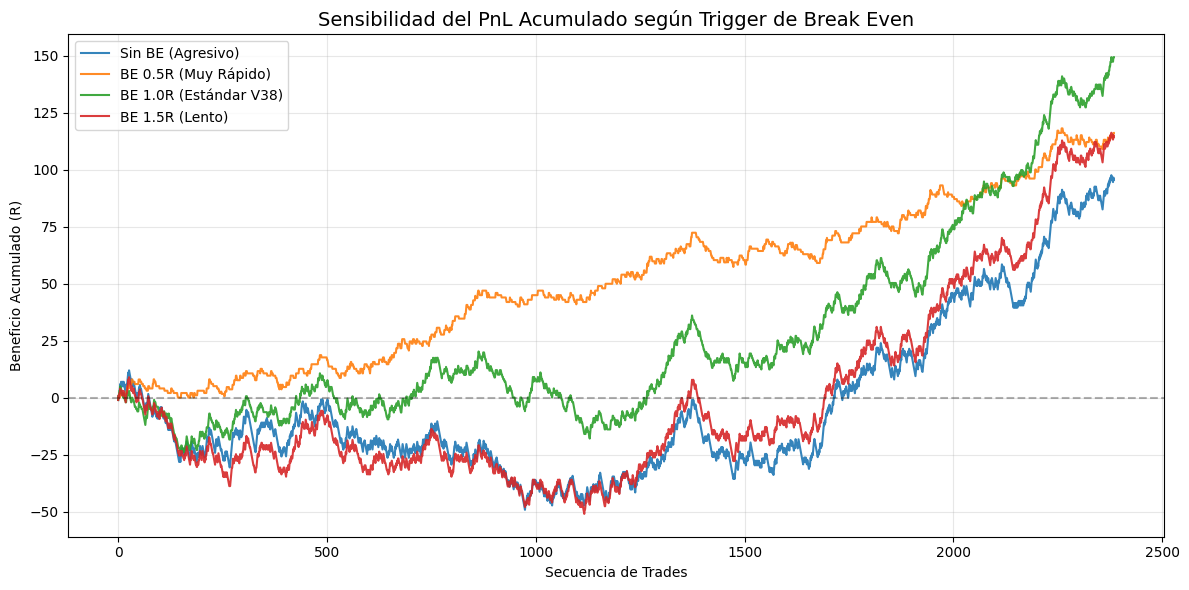

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

def ejecutar_barrido_be_v38(df_ready, df_fuente_trades):
    """
    Realiza un barrido de sensibilidad sobre el parámetro be_trigger_r 
    utilizando la función 'simular_gestion_riesgo' definida en el notebook 
    'Reasons to sell'.
    """
    
    # 1. Validación de existencia de la función en el namespace del notebook
    f_simular = globals().get('simular_gestion_riesgo')
    if f_simular is None:
        print("❌ Error: No se detecta la función 'simular_gestion_riesgo'.")
        print("Asegúrate de ejecutar la celda del notebook donde se define esta función.")
        return None

    # 2. Definición de Escenarios de Hipótesis
    # Probamos desde una gestión sin protección hasta una muy agresiva
    escenarios = {
        'Sin BE (Agresivo)': 999.0,      # Prácticamente nunca llega al BE
        'BE 0.5R (Muy Rápido)': 0.5,     # Protege muy pronto
        'BE 1.0R (Estándar V38)': 1.0,   # Baseline actual
        'BE 1.5R (Lento)': 1.5           # Permite más "ruido" antes de proteger
    }
    
    resultados_finales = []
    curvas_pnl = {}

    print(f"🧪 Iniciando barrido de sensibilidad basado en 'Reasons to sell'...")
    print(f"📦 Trades detectados para evaluar: {len(df_fuente_trades)}")
    print("-" * 70)

    for etiqueta, valor_be in escenarios.items():
        try:
            # Llamada a tu función del notebook. 
            # El breakout_delta se mantiene en 5.0 (parámetro inmutable de la V38)
            resultado = f_simular(
                df_ready, 
                df_fuente_trades, 
                breakout_delta=5.0, 
                be_trigger_r=valor_be
            )
            
            # --- Manejo Robusto del Retorno ---
            # Tu función suele devolver (stats_dict, df_results)
            stats_dict = {}
            df_res = None

            if isinstance(resultado, (tuple, list)) and len(resultado) >= 2:
                stats_dict = resultado[0]
                df_res = resultado[1]
            elif isinstance(resultado, pd.DataFrame):
                df_res = resultado
            elif isinstance(resultado, dict):
                stats_dict = resultado
                df_res = resultado.get('df_results') or resultado.get('df')

            # Validación de la columna crítica
            if df_res is None or 'pnl_r' not in df_res.columns:
                print(f"⚠️ Escenario '{etiqueta}': No se pudo extraer la columna 'pnl_r'.")
                continue
            
            # --- Cálculo de métricas comparativas ---
            pnl_total = df_res['pnl_r'].sum()
            win_rate = (df_res['pnl_r'] >= 2.0).mean()
            # Calculamos BE Rate (trades que terminaron en 0)
            be_rate = (df_res['pnl_r'] == 0).mean()
            expectancy = df_res['pnl_r'].mean()
            
            # Max Drawdown (Calculado sobre R acumulada)
            cum_pnl = df_res['pnl_r'].cumsum()
            mdd = (cum_pnl.cummax() - cum_pnl).max()

            resultados_finales.append({
                'Hipótesis BE': etiqueta,
                'Trigger (R)': valor_be if valor_be < 10 else 'N/A',
                'Nº Trades': len(df_res),
                'Win Rate %': round(win_rate * 100, 2),
                'BE Rate %': round(be_rate * 100, 2),
                'Expectancy (R)': round(expectancy, 3),
                'Max DD (R)': round(float(mdd), 2),
                'PnL Total (R)': round(pnl_total, 2)
            })
            
            curvas_pnl[etiqueta] = cum_pnl.values
            print(f"✅ {etiqueta} procesado: {pnl_total:.2f}R")
            
        except Exception as e:
            print(f"❌ Error procesando escenario {etiqueta}: {e}")

    # --- Presentación de Resultados ---
    if resultados_finales:
        df_comparativo = pd.DataFrame(resultados_finales)
        print("\n📊 TABLA COMPARATIVA: IMPACTO DE LA PROTECCIÓN DE POSICIÓN")
        # Ordenamos por Expectancy para ver cuál es más eficiente por trade
        display(df_comparativo.sort_values(by='Expectancy (R)', ascending=False))

        # Gráfico de Equidad Comparativo
        plt.figure(figsize=(12, 6))
        for etiqueta, datos in curvas_pnl.items():
            plt.plot(datos, label=f"{etiqueta}", alpha=0.9, linewidth=1.5)
        
        plt.axhline(0, color='black', linestyle='--', alpha=0.3)
        plt.title("Sensibilidad del PnL Acumulado según Trigger de Break Even", fontsize=14)
        plt.xlabel("Secuencia de Trades")
        plt.ylabel("Beneficio Acumulado (R)")
        plt.legend(loc='upper left')
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()
        
        return df_comparativo
    else:
        print("🛑 El barrido no produjo resultados. Revisa los datos de entrada.")
        return None

# --- EJECUCIÓN ---
# df_final_results es el DataFrame generado tras la Capa 2 en 'Reasons to sell'
trades_v38 = globals().get('df_final_results')

if 'df_ready' in globals() and trades_v38 is not None:
    df_analisis = ejecutar_barrido_be_v38(df_ready, trades_v38)
else:
    print("⚠️ Requisito faltante: Asegúrate de tener 'df_ready' y 'df_final_results' cargados.")

🧪 Iniciando barrido de sensibilidad extendido...
📦 Muestra: 2385 trades.
---------------------------------------------------------------------------
🚀 Iniciando gestión de riesgo para 2385 trades...
✅ Gestión completada. Win Rate: 13.33%
✅ BE 0.60R completado: 111.53R
🚀 Iniciando gestión de riesgo para 2385 trades...
✅ Gestión completada. Win Rate: 18.24%
✅ BE 0.75R completado: 124.68R
🚀 Iniciando gestión de riesgo para 2385 trades...
✅ Gestión completada. Win Rate: 21.97%
✅ BE 0.90R completado: 136.33R

📊 ANÁLISIS DE ESTABILIDAD Y RENDIMIENTO (BARRIDO FINO)


,Hipótesis,PnL Total (R),Win Rate %,Expectancy,Max DD (R),Factor Recuperación,Volatilidad (std),BE Rate %
0,BE 0.60R,111.53,12.87,0.047,20.00,5.58,0.854,65.20
1,BE 0.75R,124.68,17.53,0.052,28.76,4.33,1.003,51.28
2,BE 0.90R,136.33,21.13,0.057,34.17,3.99,1.104,40.67


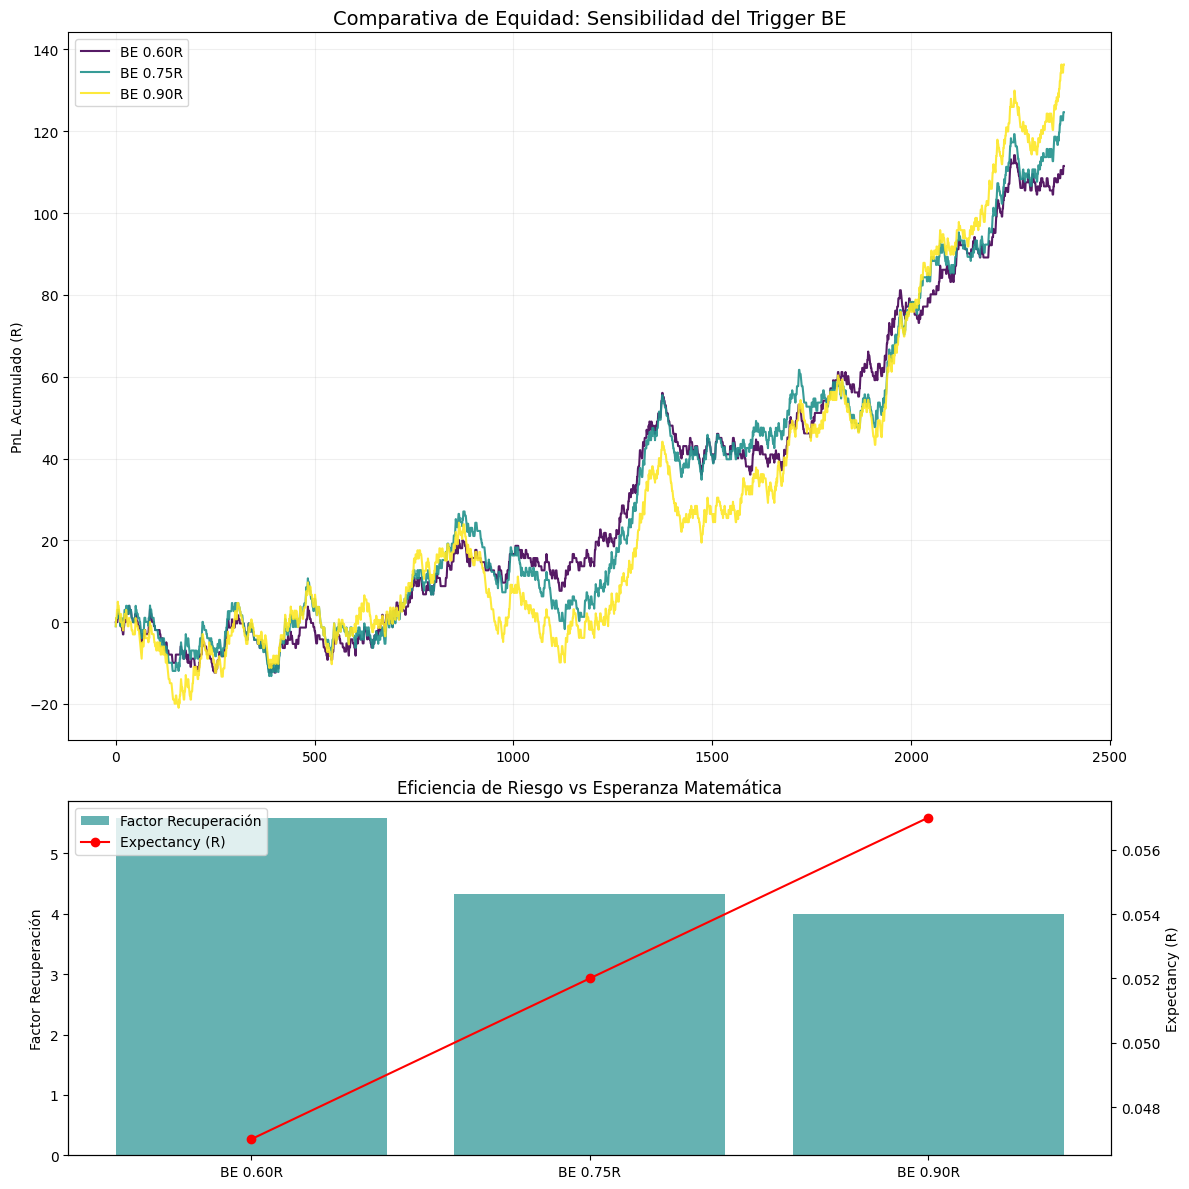

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

def ejecutar_barrido_be_v38(df_ready, df_fuente_trades, aplicar_filtro_v38=False):
    """
    Realiza un barrido de sensibilidad sobre el parámetro be_trigger_r 
    utilizando la función 'simular_gestion_riesgo' definida en el notebook.
    Incluye métricas de estabilidad para analizar la 'belleza' de la curva.
    """
    
    f_simular = globals().get('simular_gestion_riesgo')
    if f_simular is None:
        print("❌ Error: No se detecta la función 'simular_gestion_riesgo'.")
        return None

    df_trabajo = df_fuente_trades.copy()
    if aplicar_filtro_v38:
        ventanas_v38 = ["10:00-10:30", "10:30-11:00", "12:00-13:00", "14:00-15:00"]
        print(f"🔍 Filtrando trades por Ventanas de Éxito V38...")
        df_trabajo = df_trabajo[df_trabajo['ventana'].isin(ventanas_v38)]
    
    if df_trabajo.empty:
        print("⚠️ Alerta: El conjunto de trades está vacío.")
        return None

    # Escenarios extendidos basados en tu solicitud
    escenarios = {
    
        'BE 0.60R': 0.60,
        'BE 0.75R': 0.75,
        'BE 0.90R': 0.90,

    }
    
    resultados_finales = []
    curvas_pnl = {}

    print(f"🧪 Iniciando barrido de sensibilidad extendido...")
    print(f"📦 Muestra: {len(df_trabajo)} trades.")
    print("-" * 75)

    for etiqueta, valor_be in escenarios.items():
        try:
            resultado = f_simular(df_ready, df_trabajo, breakout_delta=5.0, be_trigger_r=valor_be)
            
            if isinstance(resultado, (tuple, list)):
                stats_dict, df_res = resultado[0], resultado[1]
            else:
                df_res = resultado

            pnl_total = df_res['pnl_r'].sum()
            expectancy = df_res['pnl_r'].mean()
            cum_pnl = df_res['pnl_r'].cumsum()
            
            # Métricas de Estabilidad
            mdd = (cum_pnl.cummax() - cum_pnl).max()
            # Relación Retorno/Riesgo (Factor de Recuperación)
            recovery_factor = pnl_total / mdd if mdd != 0 else pnl_total
            
            # Volatilidad de la curva (Desviación estándar de los retornos)
            volatilidad = df_res['pnl_r'].std()
            # Win Rate real (trades que terminan en Profit >= 2R)
            wr = (df_res['pnl_r'] >= 2.0).mean()

            resultados_finales.append({
                'Hipótesis': etiqueta,
                'PnL Total (R)': round(pnl_total, 2),
                'Win Rate %': round(wr * 100, 2),
                'Expectancy': round(expectancy, 3),
                'Max DD (R)': round(float(mdd), 2),
                'Factor Recuperación': round(recovery_factor, 2),
                'Volatilidad (std)': round(volatilidad, 3),
                'BE Rate %': round((df_res['pnl_r'] == 0).mean() * 100, 2)
            })
            
            curvas_pnl[etiqueta] = cum_pnl.values
            print(f"✅ {etiqueta} completado: {pnl_total:.2f}R")
            
        except Exception as e:
            print(f"❌ Error en {etiqueta}: {e}")

    if resultados_finales:
        df_comp = pd.DataFrame(resultados_finales)
        print("\n📊 ANÁLISIS DE ESTABILIDAD Y RENDIMIENTO (BARRIDO FINO)")
        # Ordenamos por Factor de Recuperación para priorizar la "belleza" / eficiencia
        display(df_comp.sort_values(by='Factor Recuperación', ascending=False))

        # Visualización
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12), gridspec_kw={'height_ratios': [2, 1]})
        
        # Gráfico 1: Curvas de Equidad
        colors = plt.cm.viridis(np.linspace(0, 1, len(curvas_pnl)))
        for i, (etiqueta, datos) in enumerate(curvas_pnl.items()):
            ax1.plot(datos, label=f"{etiqueta}", alpha=0.9, linewidth=1.5, color=colors[i])
        ax1.set_title("Comparativa de Equidad: Sensibilidad del Trigger BE", fontsize=14)
        ax1.set_ylabel("PnL Acumulado (R)")
        ax1.legend()
        ax1.grid(alpha=0.2)

        # Gráfico 2: Factor de Recuperación vs Expectancy
        ax2.bar(df_comp['Hipótesis'], df_comp['Factor Recuperación'], color='teal', alpha=0.6, label='Factor Recuperación')
        ax2_twin = ax2.twinx()
        ax2_twin.plot(df_comp['Hipótesis'], df_comp['Expectancy'], color='red', marker='o', label='Expectancy (R)')
        
        ax2.set_title("Eficiencia de Riesgo vs Esperanza Matemática")
        ax2.set_ylabel("Factor Recuperación")
        ax2_twin.set_ylabel("Expectancy (R)")
        
        lines, labels = ax2.get_legend_handles_labels()
        lines2, labels2 = ax2_twin.get_legend_handles_labels()
        ax2.legend(lines + lines2, labels + labels2, loc='upper left')
        
        plt.tight_layout()
        plt.show()

    return df_comp

# --- CONFIGURACIÓN ---
target_trades = globals().get('df_final_results')
if 'df_ready' in globals() and target_trades is not None:
    # Por defecto analizamos todo el día para ver la robustez del trigger
    df_sensibilidad = ejecutar_barrido_be_v38(df_ready, target_trades, aplicar_filtro_v38=False)